# Setup & Imports

In [39]:
import pandas as pd

import matplotlib.pyplot as plt

import json

from pathlib import Path

# Load Data

In [50]:
BASE_DIR = Path("../../data/01_raw")

metadata = []

for json_path in BASE_DIR.rglob("*.json"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

            data["_source_folder"] = json_path.parent.name
            data["_file_name"] = json_path.name

            metadata.append(data)

    except (json.JSONDecodeError, IOError) as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")

df = pd.DataFrame(metadata)
#print(df)

# Data Cleaning

In [52]:
# convert string to datetime
df['Prüfdatum'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')

# extract year from Datetime and save in extra column
df['Jahr'] = df['Prüfdatum'].dt.year.astype('Int64')


# convert Prüfnummer to number
df['Prüfnummer'] = pd.to_numeric(df['Prüfnummer'], errors='coerce')

# sort by Prüfnummer
df = df.sort_values(by='Prüfnummer')


/tmp/ipykernel_21887/177566447.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Prüfdatum'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')


# Statistical Analysis

## Reconstruction lost Documents

In [ ]:
summary = df.groupby('Jahr').agg(
    Eintraege_im_DF=('Prüfnummer', 'count'),
    Anfangs_Prüfnummer=('Prüfnummer', 'min'),
    End_Prüfnummer=('Prüfnummer', 'max')
).reset_index()

summary['Theoretische_Dokumente'] = summary['End_Prüfnummer'] - summary['Anfangs_Prüfnummer'] + 1
summary['Differenz_Fehlend'] = summary['Theoretische_Dokumente'] - summary['Eintraege_im_DF']

summary = summary[['Jahr', 'Anfangs_Prüfnummer', 'End_Prüfnummer', 'Theoretische_Dokumente', 'Eintraege_im_DF', 'Differenz_Fehlend']]

print(summary.to_string(index=False))

 Jahr  Anfangs_Prüfnummer  End_Prüfnummer  Theoretische_Dokumente  Eintraege_im_DF  Differenz_Fehlend
 1920                   2             669                     668              117                551
 1921                  22             660                     639                5                634


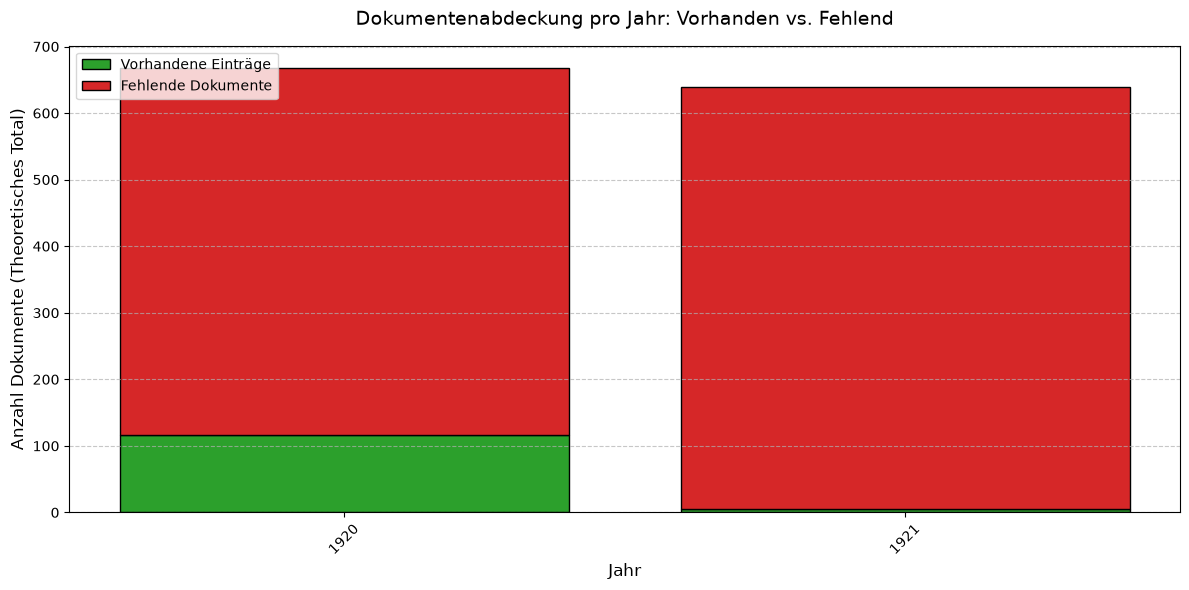

In [ ]:


# drop na
plot_df = summary.dropna(subset=['Jahr']).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    plot_df['Jahr'], 
    plot_df['Eintraege_im_DF'], 
    label='Vorhandene Einträge', 
    color='#2ca02c', # Grün für "OK"
    edgecolor='black'
)

ax.bar(
    plot_df['Jahr'], 
    plot_df['Differenz_Fehlend'], 
    bottom=plot_df['Eintraege_im_DF'], 
    label='Fehlende Dokumente', 
    color='#d62728', # Rot für "Fehlt"
    edgecolor='black'
)


ax.set_title('Dokumentenabdeckung pro Jahr: Vorhanden vs. Fehlend', fontsize=14, pad=15)
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Anzahl Dokumente (Theoretisches Total)', fontsize=12)

ax.set_xticks(plot_df['Jahr'])
ax.set_xticklabels(plot_df['Jahr'], rotation=45)

ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(loc='upper left')

plt.tight_layout()

plt.show()

## Decision 

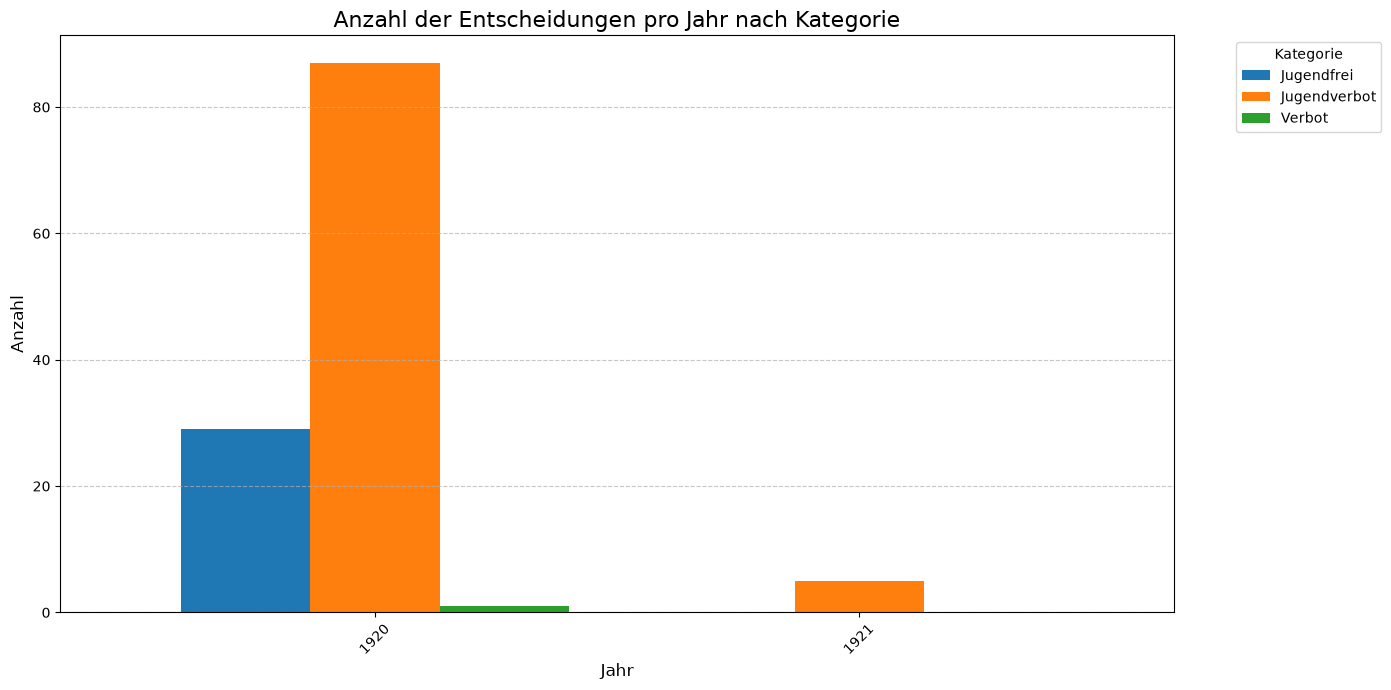

In [ ]:
df_grouped = df.groupby(['Jahr', 'Entscheidung']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Entscheidungen pro Jahr nach Kategorie', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()
